In [1]:
import sys
!{sys.executable} -m pip install opencv-python numpy

In [2]:
import cv2
import numpy as np
import glob
import os

CHECKERBOARD = (8, 5)    # sesuaikan kalau pattern-mu berbeda
SQUARE_SIZE  = 0.025     # ukuran kotak dalam meter — GANTI dengan ukuran aslimu

objp = np.zeros((CHECKERBOARD[0] * CHECKERBOARD[1], 3), np.float32)
objp[:, :2] = np.mgrid[0:CHECKERBOARD[0], 0:CHECKERBOARD[1]].T.reshape(-1, 2)
objp *= SQUARE_SIZE

objpoints, imgpoints = [], []
images = glob.glob('calib_images/*.jpg')

if len(images) == 0:
    print("ERROR: tidak ada foto di folder calib_images/")
    exit()

img_shape = None

for fname in images:
    img  = cv2.imread(fname)
    gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
    img_shape = gray.shape[::-1]

    ret, corners = cv2.findChessboardCorners(gray, CHECKERBOARD, None)

    if ret:
        objpoints.append(objp)
        corners2 = cv2.cornerSubPix(
            gray, corners, (11, 11), (-1, -1),
            (cv2.TERM_CRITERIA_EPS + cv2.TERM_CRITERIA_MAX_ITER, 30, 0.001)
        )
        imgpoints.append(corners2)
        print(f"OK:   {os.path.basename(fname)}")
    else:
        print(f"SKIP: {os.path.basename(fname)} (checkerboard tidak terdeteksi)")

print(f"\nTotal foto valid: {len(objpoints)} dari {len(images)}")

if len(objpoints) < 10:
    print("WARNING: foto valid terlalu sedikit, hasil mungkin kurang akurat")

ret, K, dist, rvecs, tvecs = cv2.calibrateCamera(
    objpoints, imgpoints, img_shape, None, None
)

print(f"\nReprojection error: {ret:.4f} px")
print("Camera Matrix K:\n", K)
print("Distortion:\n", dist)

for i, (rvec, tvec) in enumerate(zip(rvecs, tvecs)):
    projected, _ = cv2.projectPoints(objpoints[i], rvec, tvec, K, dist)
    err = cv2.norm(imgpoints[i], projected, cv2.NORM_L2) / len(projected)
    print(f"  Foto {i:02d}: {err:.4f} px")

np.save('camera_matrix.npy', K)
np.save('dist_coeffs.npy', dist)
print("\nTersimpan: camera_matrix.npy dan dist_coeffs.npy")

OK:   WIN_20260617_06_14_49_Pro.jpg
OK:   WIN_20260617_06_14_53_Pro.jpg
OK:   WIN_20260617_06_14_56_Pro.jpg
OK:   WIN_20260617_06_14_58_Pro.jpg
OK:   WIN_20260617_06_15_29_Pro.jpg
OK:   WIN_20260617_06_15_34_Pro.jpg
OK:   WIN_20260617_06_15_36_Pro.jpg
OK:   WIN_20260617_06_15_38_Pro.jpg
SKIP: WIN_20260617_06_15_40_Pro.jpg (checkerboard tidak terdeteksi)
OK:   WIN_20260617_06_15_44_Pro.jpg
OK:   WIN_20260617_06_15_49_Pro.jpg
OK:   WIN_20260617_06_15_51_Pro.jpg
OK:   WIN_20260617_06_15_53_Pro.jpg
OK:   WIN_20260617_06_15_55_Pro.jpg
OK:   WIN_20260617_06_15_59_Pro.jpg
OK:   WIN_20260617_06_16_03_Pro.jpg
OK:   WIN_20260617_06_16_06_Pro.jpg
OK:   WIN_20260617_06_16_07_Pro.jpg
OK:   WIN_20260617_06_16_09_Pro.jpg
OK:   WIN_20260617_06_16_11_Pro.jpg
OK:   WIN_20260617_06_16_34_Pro.jpg
OK:   WIN_20260617_06_16_36_Pro.jpg
OK:   WIN_20260617_06_16_41_Pro.jpg
OK:   WIN_20260617_06_16_44_Pro.jpg
OK:   WIN_20260617_06_16_46_Pro.jpg
OK:   WIN_20260617_06_16_48_Pro.jpg
OK:   WIN_20260617_06_16_50_Pro.

In [3]:
import numpy as np

# Membuka file npy
data = np.load('dist_coeffs.npy')

# Menampilkan data array
print(data)


[[ 1.65808571e-01 -1.14190190e+01  1.01111592e-02  1.34466289e-02
   4.51079296e+01]]


In [4]:
import numpy as np

# Membuka file npy
data = np.load('camera_matrix.npy')

# Menampilkan data array
print(data)


[[2.75020289e+03 0.00000000e+00 9.61651114e+02]
 [0.00000000e+00 2.73789487e+03 5.52507690e+02]
 [0.00000000e+00 0.00000000e+00 1.00000000e+00]]


In [5]:
# Reprojection error per foto (idealnya semua < 1.0 px)
for i, (rvec, tvec) in enumerate(zip(rvecs, tvecs)):
    projected, _ = cv2.projectPoints(objpoints[i], rvec, tvec, K, dist)
    err = cv2.norm(imgpoints[i], projected, cv2.NORM_L2) / len(projected)
    print(f"Foto {i:02d}: {err:.4f} px")

Foto 00: 0.5833 px
Foto 01: 0.9826 px
Foto 02: 0.7129 px
Foto 03: 0.9365 px
Foto 04: 0.7443 px
Foto 05: 0.8715 px
Foto 06: 0.9273 px
Foto 07: 0.8723 px
Foto 08: 0.8565 px
Foto 09: 0.6250 px
Foto 10: 0.5669 px
Foto 11: 0.6782 px
Foto 12: 0.8617 px
Foto 13: 0.9132 px
Foto 14: 0.5912 px
Foto 15: 1.1341 px
Foto 16: 1.1485 px
Foto 17: 0.9059 px
Foto 18: 1.0203 px
Foto 19: 0.7303 px
Foto 20: 0.6020 px
Foto 21: 0.5067 px
Foto 22: 0.6143 px
Foto 23: 0.8379 px
Foto 24: 1.1655 px
Foto 25: 0.6152 px
Foto 26: 0.4094 px
Foto 27: 0.4598 px
Foto 28: 0.6404 px
Foto 29: 0.6231 px
Foto 30: 0.9797 px
Foto 31: 0.5686 px
Foto 32: 0.6002 px


In [6]:
import cv2
import numpy as np

# Ganti dengan path foto penanda kamu
IMG_PATH = 'C:\calibration-cam\WIN_20260617_06_35_05_Pro.jpg'

# Koordinat dunia nyata (meter) — sesuaikan dengan ukuran yang kamu ukur
# Urutan: A, B, C, D, E, F
# Format: (y=samping, x=depan) — kiri negatif, kanan positif
world_points = np.float32([
    [-0.4, 2.625],   # A: kiri,   jauh
    [ 0.0, 2.625],   # B: tengah, jauh
    [ 0.4, 2.625],   # C: kanan,  jauh
    [-0.4, 1.125],   # D: kiri,   dekat
    [ 0.0, 1.125],   # E: tengah, dekat
    [ 0.4, 1.125],   # F: kanan,  dekat
])

img_points_clicked = []
img = cv2.imread(IMG_PATH)

if img is None:
    print("ERROR: foto tidak ditemukan, cek IMG_PATH")
    exit()

labels = ['A', 'B', 'C', 'D', 'E', 'F']

def click_event(event, x, y, flags, param):
    if event == cv2.EVENT_LBUTTONDOWN:
        n = len(img_points_clicked)
        if n >= 6:
            return
        img_points_clicked.append([x, y])
        cv2.circle(img, (x, y), 8, (0, 255, 0), -1)
        cv2.putText(img, labels[n], (x + 10, y - 10),
                    cv2.FONT_HERSHEY_SIMPLEX, 0.8, (0, 255, 0), 2)
        print(f"Titik {labels[n]}: piksel ({x}, {y})")
        cv2.imshow('Klik titik A-B-C-D-E-F berurutan', img)

        if len(img_points_clicked) == 6:
            print("\nSemua titik sudah diklik!")

# Resize window agar muat di layar
cv2.namedWindow('Klik titik A-B-C-D-E-F berurutan', cv2.WINDOW_NORMAL)
cv2.resizeWindow('Klik titik A-B-C-D-E-F berurutan', 1280, 720)  # sesuaikan kalau masih kebesaran

cv2.imshow('Klik titik A-B-C-D-E-F berurutan', img)
cv2.setMouseCallback('Klik titik A-B-C-D-E-F berurutan', click_event)

print("Klik selotip di gambar secara berurutan: A → B → C → D → E → F")
print("Tekan S setelah selesai klik semua 6 titik")
print("Tekan Q untuk keluar tanpa menyimpan")

while True:
    key = cv2.waitKey(1) & 0xFF
    if key == ord('s') and len(img_points_clicked) == 6:
        break
    elif key == ord('q'):
        print("Dibatalkan")
        cv2.destroyAllWindows()
        exit()

cv2.destroyAllWindows()

# Hitung homography
img_points = np.float32(img_points_clicked)
H, mask = cv2.findHomography(img_points, world_points)

np.savetxt('homography.txt', H)
print("\nHomography H:\n", H)

# Verifikasi
print("\n=== VERIFIKASI ===")
def pixel_to_ground(u, v, H):
    pt = np.array([u, v, 1.0], dtype=np.float64)
    result = H @ pt
    result /= result[2]
    return result[0], result[1]

for i, (u, v) in enumerate(img_points_clicked):
    y, x = pixel_to_ground(u, v, H)
    print(f"Titik {labels[i]}: piksel ({u},{v}) → ground ({x:.3f}m depan, {y:.3f}m samping)")
    print(f"  Expected: {x:.1f}m depan, {world_points[i][0]:.1f}m samping")

Klik selotip di gambar secara berurutan: A → B → C → D → E → F
Tekan S setelah selesai klik semua 6 titik
Tekan Q untuk keluar tanpa menyimpan
Titik A: piksel (742, 561)
Titik B: piksel (957, 561)
Titik C: piksel (1174, 562)
Titik D: piksel (426, 945)
Titik E: piksel (964, 974)
Titik F: piksel (1497, 952)

Semua titik sudah diklik!

Homography H:
 [[-1.58969794e-03  1.19391050e-05  1.51519905e+00]
 [-2.17259841e-05 -4.74060502e-04 -1.95815948e+00]
 [-6.71600318e-07 -3.30408430e-03  1.00000000e+00]]

=== VERIFIKASI ===
Titik A: piksel (742,561) → ground (2.623m depan, -0.401m samping)
  Expected: 2.6m depan, -0.4m samping
Titik B: piksel (957,561) → ground (2.628m depan, -0.001m samping)
  Expected: 2.6m depan, 0.0m samping
Titik C: piksel (1174,562) → ground (2.623m depan, 0.402m samping)
  Expected: 2.6m depan, 0.4m samping
Titik D: piksel (426,945) → ground (1.138m depan, -0.400m samping)
  Expected: 1.1m depan, -0.4m samping
Titik E: piksel (964,974) → ground (1.100m depan, 0.003m s

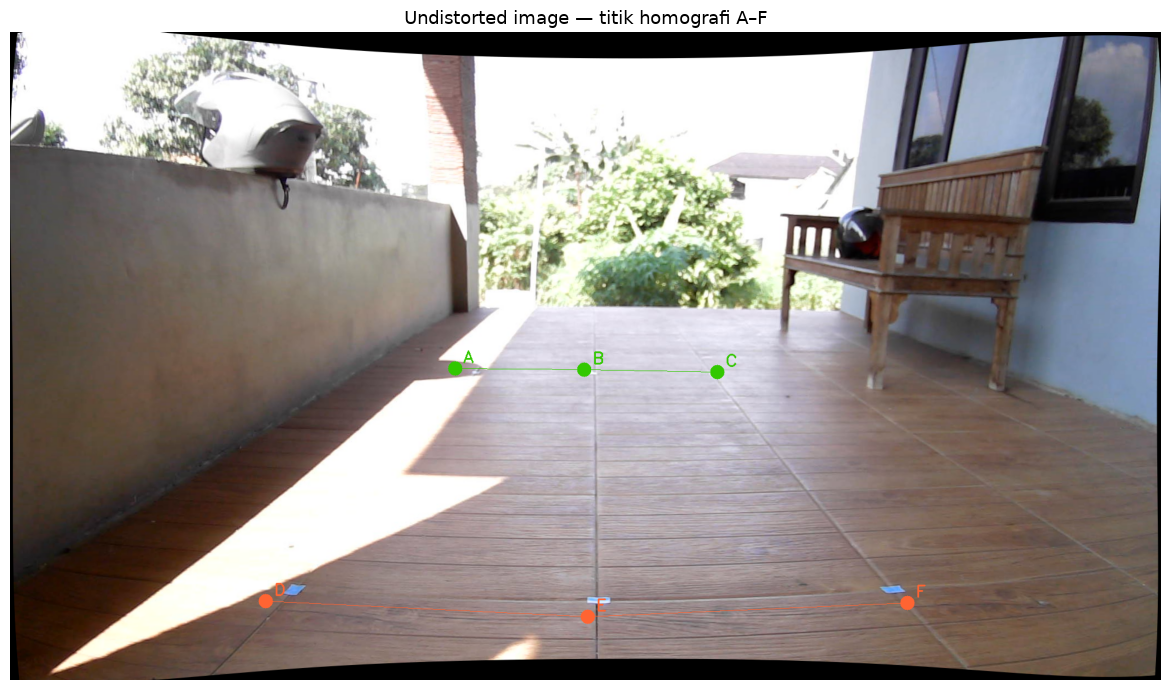

K_new: [[2.51919366e+03 0.00000000e+00 9.78123602e+02]
 [0.00000000e+00 2.51600186e+03 5.59247076e+02]
 [0.00000000e+00 0.00000000e+00 1.00000000e+00]]


In [7]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

# ── load hasil kalibrasi ──────────────────────────────────────────
K    = np.load('camera_matrix.npy')
dist = np.load('dist_coeffs.npy')
H    = np.loadtxt('homography.txt')

IMG_PATH = 'C:\\calibration-cam\\WIN_20260617_06_35_05_Pro.jpg'
img_bgr  = cv2.imread(IMG_PATH)
h, w     = img_bgr.shape[:2]

# ── undistort ─────────────────────────────────────────────────────
new_K, roi = cv2.getOptimalNewCameraMatrix(K, dist, (w, h), 1, (w, h))
undist     = cv2.undistort(img_bgr, K, dist, None, new_K)

# ── titik piksel yang sudah diklik sebelumnya ─────────────────────
img_pts = np.float32([
    [742,  560],   # A
    [957,  562],   # B
    [1179, 566],   # C
    [426,  948],   # D
    [963,  974],   # E
    [1496, 951],   # F
])
labels = ['A', 'B', 'C', 'D', 'E', 'F']
colors_bgr = [(0,200,50)] * 3 + [(50,100,255)] * 3  # hijau=jauh, merah=dekat

vis = undist.copy()
for (u, v), lbl, col in zip(img_pts.astype(int), labels, colors_bgr):
    cv2.circle(vis, (u, v), 12, col, -1)
    cv2.putText(vis, lbl, (u+14, v-10),
                cv2.FONT_HERSHEY_SIMPLEX, 0.9, col, 2)

# garis penghubung baris jauh (A-B-C) dan dekat (D-E-F)
for i in range(2):
    p1 = tuple(img_pts[i].astype(int))
    p2 = tuple(img_pts[i+1].astype(int))
    cv2.line(vis, p1, p2, (0,200,50), 1)
for i in range(3, 5):
    p1 = tuple(img_pts[i].astype(int))
    p2 = tuple(img_pts[i+1].astype(int))
    cv2.line(vis, p1, p2, (50,100,255), 1)

plt.figure(figsize=(14, 7))
plt.imshow(cv2.cvtColor(vis, cv2.COLOR_BGR2RGB))
plt.title('Undistorted image — titik homografi A–F', fontsize=13)
plt.axis('off')
plt.tight_layout()
plt.show()
print('K_new:', new_K)

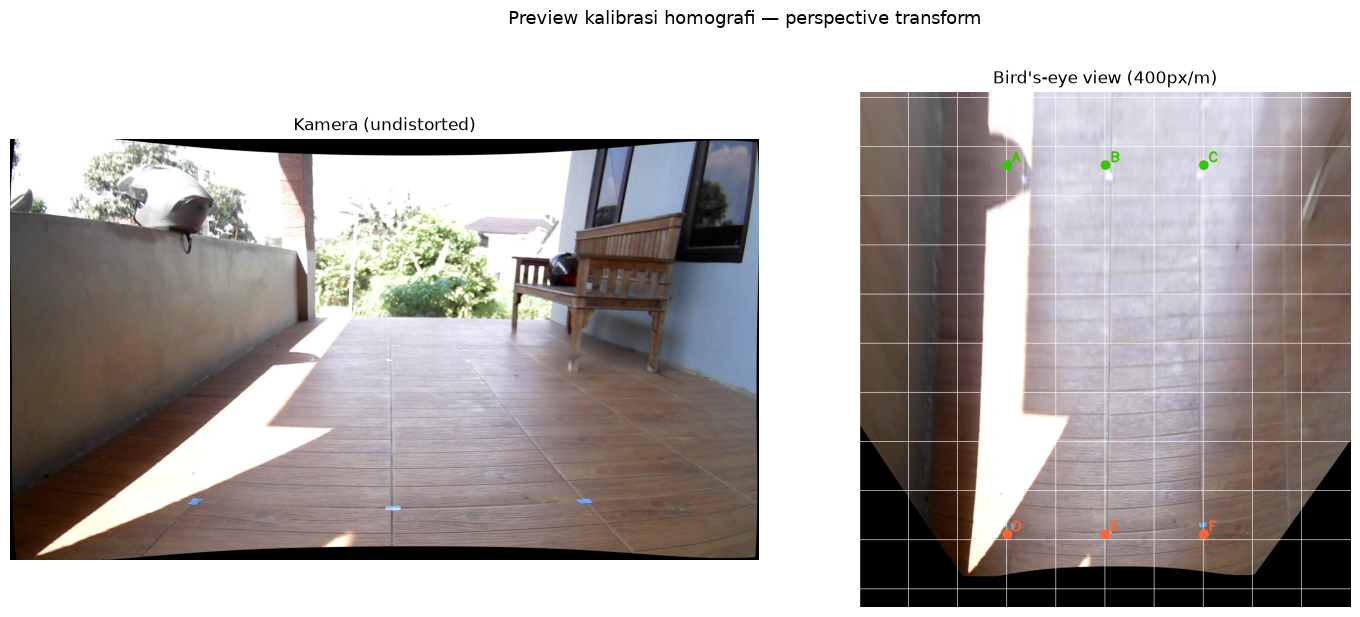

BEV size: 800×839 px  |  scale: 400 px/m


In [8]:
# ── parameter output BEV ─────────────────────────────────────────
SCALE     = 400   # pixel per meter
PAD_X_M   = 0.6   # padding kiri/kanan (meter)
PAD_Y_M   = 0.3   # padding atas/bawah (meter)

# world_points dari cell homografi: [lateral, forward] (meter)
world_pts = np.float32([
    [-0.4, 2.625],  # A
    [ 0.0, 2.625],  # B
    [ 0.4, 2.625],  # C
    [-0.4, 1.125],  # D
    [ 0.0, 1.125],  # E
    [ 0.4, 1.125],  # F
])

# rentang dunia nyata
x_min = world_pts[:, 0].min() - PAD_X_M
x_max = world_pts[:, 0].max() + PAD_X_M
y_min = world_pts[:, 1].min() - PAD_Y_M
y_max = world_pts[:, 1].max() + PAD_Y_M

bev_w = int((x_max - x_min) * SCALE)
bev_h = int((y_max - y_min) * SCALE)

# konversi world → piksel BEV  (y-axis dibalik: dekat = bawah layar)
def world_to_bev(xw, yw):
    u = (xw - x_min) * SCALE
    v = (y_max - yw) * SCALE          # flip vertikal
    return np.float32([u, v])

dst_pts = np.array([world_to_bev(x, y) for x, y in world_pts])

# perspektif transform 4 titik sudut (pakai A,C,D,F)
src_4 = img_pts[[0, 2, 3, 5]]
dst_4 = dst_pts[[0, 2, 3, 5]]
M = cv2.getPerspectiveTransform(src_4, dst_4)

bev = cv2.warpPerspective(undist, M, (bev_w, bev_h))

# overlay grid meter
for xw in np.arange(np.ceil(x_min*10)/10, x_max, 0.2):
    u = int((xw - x_min) * SCALE)
    cv2.line(bev, (u, 0), (u, bev_h), (255,255,255), 1)
for yw in np.arange(np.ceil(y_min*10)/10, y_max, 0.2):
    v = int((y_max - yw) * SCALE)
    cv2.line(bev, (0, v), (bev_w, v), (255,255,255), 1)

# overlay titik verifikasi
for pt, lbl, col in zip(dst_pts.astype(int), labels, colors_bgr):
    cv2.circle(bev, tuple(pt), 8, col, -1)
    cv2.putText(bev, lbl, (pt[0]+8, pt[1]-6),
                cv2.FONT_HERSHEY_SIMPLEX, 0.7, col, 2)

# tampilkan side-by-side
fig, axes = plt.subplots(1, 2, figsize=(15, 6))
axes[0].imshow(cv2.cvtColor(undist, cv2.COLOR_BGR2RGB))
axes[0].set_title('Kamera (undistorted)')
axes[0].axis('off')
axes[1].imshow(cv2.cvtColor(bev, cv2.COLOR_BGR2RGB))
axes[1].set_title(f'Bird\'s-eye view ({SCALE}px/m)')
axes[1].axis('off')
plt.suptitle('Preview kalibrasi homografi — perspective transform',
             fontsize=13, y=1.02)
plt.tight_layout()
plt.show()

print(f'BEV size: {bev_w}×{bev_h} px  |  scale: {SCALE} px/m')